In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("PyTorch:", torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

PyTorch: 2.11.0+cpu
Dispositivo: cpu


In [3]:
!pip install xlrd -q

In [4]:
ruta = '/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Lab04/default of credit card clients.xls'

df = pd.read_excel(ruta)

df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [5]:
df.columns = df.iloc[0]

df = df.iloc[1:].reset_index(
    drop=True
)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
df = df.apply(
    pd.to_numeric,
    errors='coerce'
)

print("Dimensiones:", df.shape)

print(
    "Valores nulos:",
    df.isnull().sum().sum()
)

Dimensiones: (30000, 25)
Valores nulos: 0


In [7]:
y = df[
    'default payment next month'
].values.astype(np.float32)

X = df.drop(
    columns=[
        'default payment next month',
        'ID'
    ]
).values.astype(np.float32)

print("X:", X.shape)
print("y:", y.shape)

print(
    "Clase 0:",
    np.sum(y == 0)
)

print(
    "Clase 1:",
    np.sum(y == 1)
)

X: (30000, 23)
y: (30000,)
Clase 0: 23364
Clase 1: 6636


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)

Train: (24000, 23) (24000,)
Test: (6000, 23) (6000,)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
).astype(np.float32)

X_test_scaled = scaler.transform(
    X_test
).astype(np.float32)

print(
    "Train normalizado:",
    X_train_scaled.shape
)

print(
    "Test normalizado:",
    X_test_scaled.shape
)

Train normalizado: (24000, 23)
Test normalizado: (6000, 23)


In [10]:
y_train = y_train.reshape(
    -1,
    1
)

y_test = y_test.reshape(
    -1,
    1
)

print(y_train.shape)
print(y_test.shape)

(24000, 1)
(6000, 1)


In [11]:
class DatasetPersonalizado(
    torch.utils.data.Dataset
):

    def __init__(self, X, Y):

        self.X = torch.from_numpy(
            X
        ).float()

        self.Y = torch.from_numpy(
            Y
        ).float()


    def __len__(self):

        return len(self.X)


    def __getitem__(self, ix):

        return (
            self.X[ix],
            self.Y[ix]
        )

In [12]:
dataset = {

    'train': DatasetPersonalizado(
        X_train_scaled,
        y_train
    ),

    'test': DatasetPersonalizado(
        X_test_scaled,
        y_test
    )
}

print(
    "Train:",
    len(dataset['train'])
)

print(
    "Test:",
    len(dataset['test'])
)

Train: 24000
Test: 6000


In [13]:
dataloader = {

    'train': torch.utils.data.DataLoader(
        dataset['train'],
        batch_size=64,
        shuffle=True
    ),

    'test': torch.utils.data.DataLoader(
        dataset['test'],
        batch_size=64,
        shuffle=False
    )
}

In [14]:
x_b, y_b = next(
    iter(
        dataloader['train']
    )
)

print(
    "X:",
    x_b.shape
)

print(
    "y:",
    y_b.shape
)

X: torch.Size([64, 23])
y: torch.Size([64, 1])


In [15]:
class RegresionLogistica(
    torch.nn.Module
):

    def __init__(self):

        super(
            RegresionLogistica,
            self
        ).__init__()

        self.linear = torch.nn.Linear(
            23,
            1
        )


    def forward(self, x):

        return self.linear(x)

In [16]:
model = RegresionLogistica().to(
    device
)

criterion = (
    torch.nn.BCEWithLogitsLoss()
)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

print(model)

RegresionLogistica(
  (linear): Linear(in_features=23, out_features=1, bias=True)
)


In [17]:
def fit(
    model,
    dataloader,
    optimizer,
    epochs=200,
    log_each=20
):

    criterion = (
        torch.nn.BCEWithLogitsLoss()
    )

    train_loss = []
    test_loss = []

    best_loss = float('inf')


    for e in range(
        1,
        epochs + 1
    ):

        model.train()

        _train_loss = []


        for x_b, y_b in dataloader['train']:

            x_b = x_b.to(device)
            y_b = y_b.to(device)

            logits = model(x_b)

            loss = criterion(
                logits,
                y_b
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            _train_loss.append(
                loss.item()
            )


        train_loss.append(
            np.mean(_train_loss)
        )


        model.eval()

        _test_loss = []


        with torch.no_grad():

            for x_b, y_b in dataloader['test']:

                x_b = x_b.to(device)
                y_b = y_b.to(device)

                logits = model(x_b)

                loss = criterion(
                    logits,
                    y_b
                )

                _test_loss.append(
                    loss.item()
                )


        test_loss.append(
            np.mean(_test_loss)
        )


        if test_loss[-1] < best_loss:

            best_loss = test_loss[-1]

            torch.save(
                model.state_dict(),
                'mejor_modelo_lab04.pt'
            )


        if not e % log_each:

            print(
                f"Epoch {e}/{epochs} "
                f"loss {train_loss[-1]:.5f} "
                f"test_loss {test_loss[-1]:.5f}"
            )


    model.load_state_dict(
        torch.load(
            'mejor_modelo_lab04.pt',
            map_location=device
        )
    )


    return {
        'epoch':
            list(
                range(
                    1,
                    len(train_loss) + 1
                )
            ),

        'loss':
            train_loss,

        'test_loss':
            test_loss
    }

In [18]:
model = RegresionLogistica().to(
    device
)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

hist = fit(
    model,
    dataloader,
    optimizer,
    epochs=200,
    log_each=20
)

Epoch 20/200 loss 0.46357 test_loss 0.47112
Epoch 40/200 loss 0.46353 test_loss 0.47105
Epoch 60/200 loss 0.46354 test_loss 0.47105
Epoch 80/200 loss 0.46346 test_loss 0.47134
Epoch 100/200 loss 0.46352 test_loss 0.47110
Epoch 120/200 loss 0.46350 test_loss 0.47081
Epoch 140/200 loss 0.46349 test_loss 0.47102
Epoch 160/200 loss 0.46345 test_loss 0.47095
Epoch 180/200 loss 0.46352 test_loss 0.47080
Epoch 200/200 loss 0.46349 test_loss 0.47110


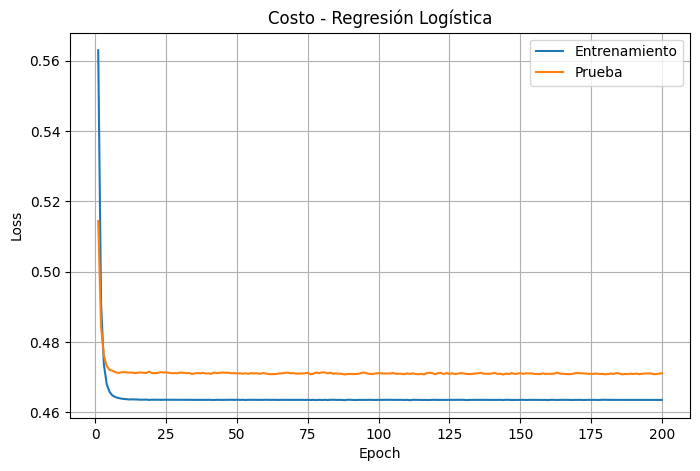

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist['epoch'],
    hist['loss'],
    label='Entrenamiento'
)

plt.plot(
    hist['epoch'],
    hist['test_loss'],
    label='Prueba'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Costo - Regresión Logística')

plt.legend()
plt.grid()
plt.show()

In [20]:
model.eval()

probabilidades = []
predicciones = []
valores_reales = []

with torch.no_grad():

    for x_b, y_b in dataloader['test']:

        x_b = x_b.to(device)

        logits = model(x_b)

        probs = torch.sigmoid(
            logits
        )

        preds = (
            probs >= 0.5
        ).float()

        probabilidades.extend(
            probs.cpu().numpy()
        )

        predicciones.extend(
            preds.cpu().numpy()
        )

        valores_reales.extend(
            y_b.numpy()
        )

In [21]:
probabilidades = np.array(
    probabilidades
).flatten()

y_pred = np.array(
    predicciones
).flatten()

y_real = np.array(
    valores_reales
).flatten()

print(
    "Cantidad de predicciones:",
    len(y_pred)
)

Cantidad de predicciones: 6000


In [22]:
accuracy = accuracy_score(
    y_real,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

print(
    "Accuracy %:",
    accuracy * 100
)

Accuracy: 0.8078333333333333
Accuracy %: 80.78333333333333


In [23]:
matriz = confusion_matrix(
    y_real,
    y_pred
)

print(
    "Matriz de confusión:"
)

print(matriz)

Matriz de confusión:
[[4538  135]
 [1018  309]]


In [24]:
reporte = classification_report(
    y_real,
    y_pred,
    digits=4
)

print(
    "REPORTE DE CLASIFICACIÓN"
)

print(reporte)

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

         0.0     0.8168    0.9711    0.8873      4673
         1.0     0.6959    0.2329    0.3490      1327

    accuracy                         0.8078      6000
   macro avg     0.7564    0.6020    0.6181      6000
weighted avg     0.7901    0.8078    0.7682      6000



In [25]:
for i in range(20):

    print(
        f"Real: {int(y_real[i])} "
        f"| Probabilidad: {probabilidades[i]:.4f} "
        f"| Predicción: {int(y_pred[i])}"
    )

Real: 0 | Probabilidad: 0.1092 | Predicción: 0
Real: 0 | Probabilidad: 0.1194 | Predicción: 0
Real: 0 | Probabilidad: 0.2183 | Predicción: 0
Real: 1 | Probabilidad: 0.1003 | Predicción: 0
Real: 0 | Probabilidad: 0.0286 | Predicción: 0
Real: 0 | Probabilidad: 0.2128 | Predicción: 0
Real: 0 | Probabilidad: 0.1338 | Predicción: 0
Real: 0 | Probabilidad: 0.1528 | Predicción: 0
Real: 0 | Probabilidad: 0.0787 | Predicción: 0
Real: 0 | Probabilidad: 0.1917 | Predicción: 0
Real: 0 | Probabilidad: 0.3301 | Predicción: 0
Real: 0 | Probabilidad: 0.0810 | Predicción: 0
Real: 1 | Probabilidad: 0.0756 | Predicción: 0
Real: 0 | Probabilidad: 0.1773 | Predicción: 0
Real: 0 | Probabilidad: 0.2002 | Predicción: 0
Real: 0 | Probabilidad: 0.4290 | Predicción: 0
Real: 0 | Probabilidad: 0.0167 | Predicción: 0
Real: 1 | Probabilidad: 0.3556 | Predicción: 0
Real: 0 | Probabilidad: 0.1812 | Predicción: 0
Real: 0 | Probabilidad: 0.1679 | Predicción: 0


In [26]:
carpeta = (
    '/content/drive/MyDrive/'
    'Colab Notebooks/'
    'Machine Learning Soto/'
    'LabPyTorch/'
    'Lab04'
)

os.makedirs(
    carpeta,
    exist_ok=True
)

PATH = os.path.join(
    carpeta,
    'lab04_checkpoint.pt'
)

torch.save(
    {
        'model_state_dict':
            model.state_dict(),

        'optimizer_state_dict':
            optimizer.state_dict(),

        'scaler_mean':
            scaler.mean_,

        'scaler_scale':
            scaler.scale_,

        'accuracy':
            accuracy,

        'confusion_matrix':
            matriz
    },

    PATH
)

print(
    "Modelo guardado en:"
)

print(PATH)

Modelo guardado en:
/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/LabPyTorch/Lab04/lab04_checkpoint.pt


In [27]:
print(
    "Existe:",
    os.path.exists(PATH)
)

Existe: True


In [28]:
checkpoint = torch.load(
    PATH,
    map_location=device,
    weights_only=False
)

print(
    "Checkpoint cargado"
)

Checkpoint cargado


In [29]:
modelo_cargado = (
    RegresionLogistica()
    .to(device)
)

modelo_cargado.load_state_dict(
    checkpoint[
        'model_state_dict'
    ]
)

modelo_cargado.eval()

print(
    "Modelo recuperado correctamente"
)

Modelo recuperado correctamente


In [30]:
print(
    "LABORATORIO 04 PYTORCH COMPLETADO"
)

print(
    "Dataset       : Credit Card Default"
)

print(
    "Ejemplos      : 30000"
)

print(
    "Características: 23"
)

print(
    "Objetivo      : default payment next month"
)

print(
    "Clases        : 0 / 1"
)

print(
    "Dataset       : OK"
)

print(
    "DataLoader    : OK"
)

print(
    "BCEWithLogits : OK"
)

print(
    "SGD           : OK"
)

print(
    "Sigmoide      : OK"
)

print(
    "Accuracy      : OK"
)

print(
    "Matriz confusión: OK"
)

print(
    "Checkpoint    : OK"
)

LABORATORIO 04 PYTORCH COMPLETADO
Dataset       : Credit Card Default
Ejemplos      : 30000
Características: 23
Objetivo      : default payment next month
Clases        : 0 / 1
Dataset       : OK
DataLoader    : OK
BCEWithLogits : OK
SGD           : OK
Sigmoide      : OK
Accuracy      : OK
Matriz confusión: OK
Checkpoint    : OK
